# Classificação binária com EfficientNet (Demented vs NonDemented)

In [1]:
# ===== 0) Setup e Config =====
import random
from pathlib import Path
import numpy as np
import pandas as pd

import tensorflow as tf

import nibabel as nib
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

# Caminhos
# Resolve o diretório raiz do projeto para que 'database' seja encontrado
ROOT = Path('.')
for candidate in [Path('.'), Path('..'), Path('../..')]:
    if (candidate / 'database').exists():
        ROOT = candidate
        break
DB_ROOT = ROOT / 'database'
AXL_DIR = DB_ROOT / 'axl'  # Arquivos .nii.gz com padrão {MRI ID}_axl.nii.gz
TRAIN_DIR = DB_ROOT / 'treino'
TEST_DIR  = DB_ROOT / 'teste'

OASIS_CSV = DB_ROOT / 'oasis_longitudinal_demographic.csv'

# Hiperparâmetros
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 20
LEARNING_RATE = 0.0001

# Mapeamento de classes
CLASS_MAP = {'NonDemented': 0, 'Demented': 1}

TF version: 2.20.0
GPUs: []


In [3]:
# ===== 1) Carregar OASIS, alinhar com volumes e fazer splits =====

df_oasis = pd.read_csv(OASIS_CSV, sep=';', decimal=',')

# Normaliza classes
df_oasis['Group'] = df_oasis['Group'].astype(str).str.strip()

df_oasis = df_oasis[df_oasis['Group'].isin(['Nondemented', 'Demented'])].copy()
df_oasis['Group'] = df_oasis['Group'].replace({'Nondemented': 'NonDemented'})

df_oasis['MRI ID'] = df_oasis['MRI ID'].astype(str).str.strip()
df_oasis['y'] = df_oasis['Group'].map(CLASS_MAP)

print('Distribuição original (apenas NonDemented/Demented):')
print(df_oasis['Group'].value_counts())

# Descobrir quais MRI IDs têm arquivo *_axl.nii.gz na pasta AXL_DIR
def filename_to_mri_id(path: Path) -> str:
    base = path.name
    base = base.replace('.nii.gz', '').replace('.nii', '')
    if base.endswith('_axl'):
        base = base[:-4]
    return base

nii_paths = sorted(AXL_DIR.glob('*_axl.nii.gz'))
valid_ids = {filename_to_mri_id(p) for p in nii_paths}

df_oasis_imgs = df_oasis[df_oasis['MRI ID'].isin(valid_ids)].copy()

print('\nApós cruzar com volumes existentes:')
print(df_oasis_imgs['Group'].value_counts())

trainval_df, test_df = train_test_split(
    df_oasis_imgs,
    test_size=0.2,
    stratify=df_oasis_imgs['y'],
    random_state=SEED
)

train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.2,
    stratify=trainval_df['y'],
    random_state=SEED
)

print('\nTreino:')
print(train_df['Group'].value_counts())
print('\nValidação:')
print(val_df['Group'].value_counts())
print('\nTeste:')
print(test_df['Group'].value_counts())

def add_paths(df):
    df = df.copy()
    df['path'] = df['MRI ID'].apply(lambda mid: str(AXL_DIR / f"{mid}_axl.nii.gz"))
    df['mri'] = df['MRI ID']
    return df[['path', 'y', 'mri']]

train_paths = add_paths(train_df)
val_paths   = add_paths(val_df)
test_paths  = add_paths(test_df)

print(f"\nTrain volumes: {len(train_paths)}")
print(f"Val   volumes: {len(val_paths)}")
print(f"Test  volumes: {len(test_paths)}")

Distribuição original (apenas NonDemented/Demented):
Group
NonDemented    190
Demented       146
Name: count, dtype: int64

Após cruzar com volumes existentes:
Group
NonDemented    190
Demented       146
Name: count, dtype: int64

Treino:
Group
NonDemented    121
Demented        93
Name: count, dtype: int64

Validação:
Group
NonDemented    31
Demented       23
Name: count, dtype: int64

Teste:
Group
NonDemented    38
Demented       30
Name: count, dtype: int64

Train volumes: 214
Val   volumes: 54
Test  volumes: 68


In [6]:
# Função para carregar e pré-processar o arquivo .nii.gz
def load_and_preprocess_nifti(path, label):
    # 1. Carregar o Nifti
    def _load_nifti(path_tensor):
        path_str = path_tensor.numpy().decode('utf-8')
        img = nib.load(path_str).get_fdata()
        return img.astype(np.float32)
    
    image_data = tf.py_function(_load_nifti, [path], tf.float32)
    
    # Definir o shape manualmente.
    image_data.set_shape([None, None])
    
    # 2. Normalizar
    image_data = image_data / tf.reduce_max(image_data)
    
    # 3. Redimensionar para o tamanho do EfficientNet
    image_data = tf.expand_dims(image_data, axis=-1)
    image_data = tf.image.resize(image_data, [IMG_SIZE, IMG_SIZE])
    
    # 4. Converter de 1 canal (Grayscale) para 3 canais (RGB)
    image_data = tf.image.grayscale_to_rgb(image_data)
    
    # 5. Aplicar pré-processamento do EfficientNet
    image_data = tf.keras.applications.efficientnet.preprocess_input(image_data)
    
    # Definir o shape final
    image_data.set_shape([IMG_SIZE, IMG_SIZE, 3])
    
    return image_data, label

In [7]:
def create_dataset(df, batch_size=BATCH_SIZE, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((df['path'], df['y']))
    
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED)
    
    # Mapear a função de carregamento
    dataset = dataset.map(load_and_preprocess_nifti, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Agrupar em lotes
    dataset = dataset.batch(batch_size)
    
    # Otimizar performance
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# Criar os datasets
train_ds = create_dataset(train_paths, is_training=True)
val_ds = create_dataset(val_paths, is_training=False)
test_ds = create_dataset(test_paths, is_training=False)

print("Pipelines de dados criados.")

Pipelines de dados criados.


In [ ]:
def build_model(img_size=IMG_SIZE):
    # 1. Carregar a base pré-treinada
    base_model = EfficientNetB0(
        weights='imagenet',       # Usar pesos da ImageNet 
        include_top=False,        # Não incluir o classificador final da ImageNet
        input_shape=(img_size, img_size, 3)
    )
    
    # 2. Congelar a base (não vamos treinar os pesos da ImageNet)
    base_model.trainable = False
    
    # 3. Adicionar nosso cabeçalho de classificação
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x) # Dropout para regularização
    
    # Camada de saída: 1 neurônio (Demented/NonDemented) com ativação sigmoid
    outputs = Dense(1, activation='sigmoid')(x)
    
    # 4. Criar e compilar o modelo
    model = Model(inputs, outputs)
    
    model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy', 
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.TrueNegatives(name='tn'),
        tf.keras.metrics.FalsePositives(name='fp')
        ]
    )
    
    return model, base_model

model, base_model = build_model()
model.summary()

In [ ]:
print("Iniciando o treinamento...")

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
)

print("Treinamento concluído.")

Iniciando o treinamento...
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 536ms/step - accuracy: 0.5794 - fp: 1.0000 - loss: 0.6907 - sensitivity: 0.0430 - tn: 120.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6822 - val_sensitivity: 0.0000e+00 - val_tn: 31.0000
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.5607 - fp: 6.0000 - loss: 0.6893 - sensitivity: 0.0538 - tn: 115.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6822 - val_sensitivity: 0.0000e+00 - val_tn: 31.0000
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 293ms/step - accuracy: 0.5701 - fp: 6.0000 - loss: 0.6832 - sensitivity: 0.0753 - tn: 115.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6822 - val_sensitivity: 0.0000e+00 - val_tn: 31.0000
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.5654 - fp: 8.0000 - loss: 0.6870 - sensitivity: 0.0860 - tn: 113.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6823 - val_sensitivity: 0.0000e+00 - 

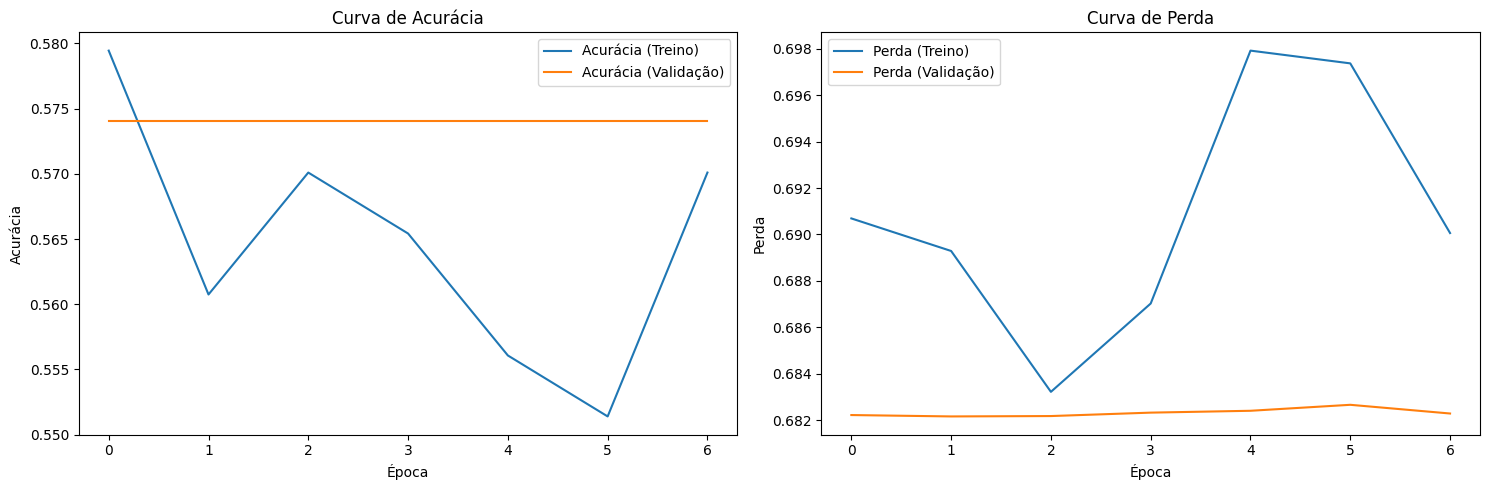

In [13]:
def plot_learning_curves(history):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico de Acurácia
    ax[0].plot(history.history['accuracy'], label='Acurácia (Treino)')
    ax[0].plot(history.history['val_accuracy'], label='Acurácia (Validação)')
    ax[0].set_title('Curva de Acurácia')
    ax[0].set_xlabel('Época')
    ax[0].set_ylabel('Acurácia')
    ax[0].legend()
    
    # Gráfico de Perda
    ax[1].plot(history.history['loss'], label='Perda (Treino)')
    ax[1].plot(history.history['val_loss'], label='Perda (Validação)')
    ax[1].set_title('Curva de Perda')
    ax[1].set_xlabel('Época')
    ax[1].set_ylabel('Perda')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

In [ ]:
# --- PASSO 2: PREPARAR PARA O FINE-TUNING ---

print("Iniciando preparação para o Fine-Tuning...")

# 1. Descongelar o modelo base
base_model.trainable = True

# 2. Definir uma taxa de aprendizado menor
LEARNING_RATE_FT = LEARNING_RATE / 10

# 3. Re-compilar o modelo com a nova taxa

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_FT),
    loss='binary_crossentropy',
    metrics=[
        'accuracy', 
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.TrueNegatives(name='tn'),
        tf.keras.metrics.FalsePositives(name='fp')
    ]
)

print(f"Modelo re-compilado para fine-tuning com LR = {LEARNING_RATE_FT}")
model.summary()

In [ ]:
# --- CONTINUAR O TREINAMENTO (FINE-TUNING) ---

# Quantas épocas a mais para o fine-tuning
FINE_TUNE_EPOCHS = 15 
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

print("Iniciando fine-tuning...")

history_fine_tune = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history.epoch[-1],
    validation_data=val_ds
)

print("Fine-tuning concluído.")

Iniciando fine-tuning...
Epoch 7/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.4486 - fp: 93.0000 - loss: 0.7294 - sensitivity: 0.7312 - tn: 28.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6864 - val_sensitivity: 0.0000e+00 - val_tn: 31.0000
Epoch 8/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5187 - fp: 84.0000 - loss: 0.7195 - sensitivity: 0.7957 - tn: 37.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6884 - val_sensitivity: 0.0000e+00 - val_tn: 31.0000
Epoch 9/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5234 - fp: 75.0000 - loss: 0.7051 - sensitivity: 0.7097 - tn: 46.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6895 - val_sensitivity: 0.0000e+00 - val_tn: 31.0000
Epoch 10/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5701 - fp: 65.0000 - loss: 0.6817 - sensitivity: 0.7097 - tn: 56.0000 - val_accuracy: 0.5741 - val_fp: 0.0000e+00 - val_loss: 0.6896 - val_sensitivity: 0.0000e+00 - val_tn: 31

Avaliando no conjunto de teste...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.5588 - fp: 18.0000 - loss: 0.6899 - sensitivity: 0.6000 - tn: 20.0000

Métricas de Teste:
Loss: 0.6899
Accuracy: 0.5588
Sensitivity (Recall): 0.6000
Specificity (Calculada): 0.5263  (TN=20, FP=18)
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 609ms/step

Matriz de Confusão (Teste):


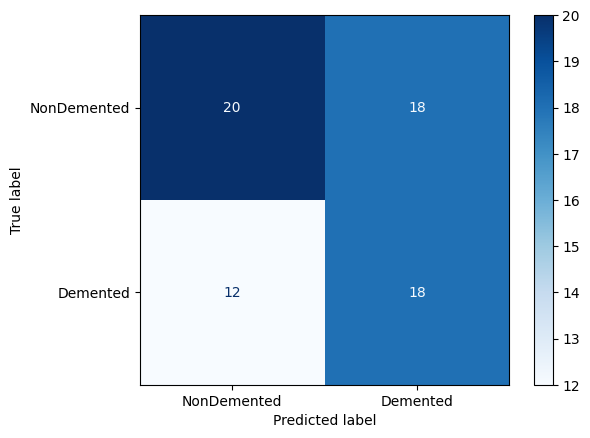


Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 NonDemented       0.62      0.53      0.57        38
    Demented       0.50      0.60      0.55        30

    accuracy                           0.56        68
   macro avg       0.56      0.56      0.56        68
weighted avg       0.57      0.56      0.56        68



In [ ]:
print("Avaliando no conjunto de teste...")

# 1. Avaliação geral
results = model.evaluate(test_ds)
loss = results[0]
accuracy = results[1]
sensitivity = results[2]
tn = results[3] # Verdadeiros Negativos (True Negatives)
fp = results[4] # Falsos Positivos (False Positives)

# 2. Calcular Especificidade manualmente
specificity = tn / (tn + fp + 1e-7) 

print("\nMétricas de Teste:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity (Calculada): {specificity:.4f}  (TN={int(tn)}, FP={int(fp)})")


# 3. Obter predições para a matriz de confusão
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 4. Calcular e exibir Matriz de Confusão
print("\nMatriz de Confusão (Teste):")
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_MAP.keys())
disp.plot(cmap='Blues')
plt.show()

# 5. Relatório de Classificação
print("\nRelatório de Classificação (Teste):")
print(classification_report(y_true, y_pred, target_names=CLASS_MAP.keys()))

In [ ]:
# --- PREPARAÇÃO PARA REGRESSÃO (IDADE) ---

# 1. Calcular Min/Max APENAS no conjunto de treino
age_min = train_df['Age'].min()
age_max = train_df['Age'].max()

print(f"Idade Mín (Treino): {age_min}")
print(f"Idade Máx (Treino): {age_max}")

# 2. Nova função de 'add_paths' que normaliza a idade
def add_paths_regression_norm(df, v_min, v_max):
    df = df.copy()
    df['path'] = df['MRI ID'].apply(lambda mid: str(AXL_DIR / f"{mid}_axl.nii.gz"))
    
    # === MUDANÇA AQUI: Normalizar 'Age' para [0, 1] ===
    df['y'] = (df['Age'] - v_min) / (v_max - v_min)
    
    # Guardar a idade original para avaliação futura
    df['age_original'] = df['Age'] 
    
    return df[['path', 'y', 'age_original']]

# 3. Criar os dataframes de caminhos normalizados
train_paths_reg = add_paths_regression_norm(train_df, age_min, age_max)
val_paths_reg   = add_paths_regression_norm(val_df, age_min, age_max)
test_paths_reg  = add_paths_regression_norm(test_df, age_min, age_max)

print("\nDataframes de caminhos para Regressão (Normalizados):")
print(train_paths_reg.head())

# 4. Criar os datasets (re-usando a Célula 4)
train_ds_reg = create_dataset(train_paths_reg, is_training=True)
val_ds_reg = create_dataset(val_paths_reg, is_training=False)

test_ds_reg = create_dataset(test_paths_reg, is_training=False)

print("\nPipelines de dados de Regressão (Normalizados) criados.")

Idade Mín (Treino): 60
Idade Máx (Treino): 96

Dataframes de caminhos para Regressão (Normalizados):
                                         path         y  age_original
30   ..\database\axl\OAS2_0017_MR3_axl.nii.gz  0.583333            81
41   ..\database\axl\OAS2_0022_MR1_axl.nii.gz  0.027778            61
145  ..\database\axl\OAS2_0068_MR1_axl.nii.gz  0.777778            88
258  ..\database\axl\OAS2_0126_MR1_axl.nii.gz  0.388889            74
299  ..\database\axl\OAS2_0146_MR1_axl.nii.gz  0.555556            80

Pipelines de dados de Regressão (Normalizados) criados.


In [ ]:
def build_regression_model(img_size=IMG_SIZE):
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False
    
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    
    # === Adicionar ativação 'sigmoid' ===
    # A saida linear estava errando por muito
    # Força a saída a ficar entre [0, 1], assim como nossos rótulos
    outputs = Dense(1, activation='sigmoid')(x) 
    
    model = Model(inputs, outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mean_absolute_error', 
        metrics=['mae', 'mse'] 
    )
    
    return model, base_model

# Crie o modelo novamente
reg_model, reg_base_model = build_regression_model()
reg_model.summary()

In [ ]:
# --- TREINAMENTO (PASSO 1) DO REGRESSOR ---

print("Iniciando treinamento (Passo 1) do Regressor de Idade...")

# Usamos os datasets de regressão (_reg)
reg_history = reg_model.fit(
    train_ds_reg,
    epochs=EPOCHS,
    validation_data=val_ds_reg
)

print("Treinamento (Passo 1) concluído.")

Iniciando treinamento (Passo 1) do Regressor de Idade...
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 453ms/step - loss: 0.1731 - mae: 0.1731 - mse: 0.0470 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0509
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step - loss: 0.1773 - mae: 0.1773 - mse: 0.0474 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0504
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - loss: 0.1743 - mae: 0.1743 - mse: 0.0459 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0505
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step - loss: 0.1792 - mae: 0.1792 - mse: 0.0480 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0505
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - loss: 0.1740 - mae: 0.1740 - mse: 0.0457 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0505
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - loss: 0.1747 - mae: 0.1747 - mse: 0.0456 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0506
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 2

In [18]:
# --- TREINAMENTO (PASSO 2) DO REGRESSOR (FINE-TUNING) ---

print("Iniciando Fine-Tuning do Regressor de Idade...")

# 1. Descongelar
reg_base_model.trainable = True

# 2. Re-compilar com LR baixa
LEARNING_RATE_FT = LEARNING_RATE / 10
reg_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_FT),
    loss='mean_absolute_error',
    metrics=['mae', 'mse']
)

# 3. Continuar o treino
FINE_TUNE_EPOCHS = 15 
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS
reg_history_ft = reg_model.fit(
    train_ds_reg,
    epochs=TOTAL_EPOCHS,
    initial_epoch=reg_history.epoch[-1],
    validation_data=val_ds_reg
)

print("Fine-Tuning do Regressor concluído.")

Iniciando Fine-Tuning do Regressor de Idade...
Epoch 20/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - loss: 0.1882 - mae: 0.1882 - mse: 0.0535 - val_loss: 0.1764 - val_mae: 0.1764 - val_mse: 0.0505
Epoch 21/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.1737 - mae: 0.1737 - mse: 0.0473 - val_loss: 0.1825 - val_mae: 0.1825 - val_mse: 0.0510
Epoch 22/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.1643 - mae: 0.1643 - mse: 0.0419 - val_loss: 0.1859 - val_mae: 0.1859 - val_mse: 0.0522
Epoch 23/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.1660 - mae: 0.1660 - mse: 0.0423 - val_loss: 0.1909 - val_mae: 0.1909 - val_mse: 0.0544
Epoch 24/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.1661 - mae: 0.1661 - mse: 0.0429 - val_loss: 0.1964 - val_mae: 0.1964 - val_mse: 0.0572
Epoch 25/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 0.1464 - mae: 0.1464 - mse: 0.0350 - val_loss: 0.1997 - val_mae: 0.1997 - val_mse: 0.0588
Epoch 26/35
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 

Avaliando Regressor de Idade no conjunto de teste...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 0.1878 - mae: 0.1878 - mse: 0.0532

Métricas de Teste (na escala normalizada [0, 1]):
Loss (MAE): 0.1878
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 616ms/step

===== RESULTADO FINAL =====
O Erro Médio Absoluto (MAE) real é: 6.76 anos.


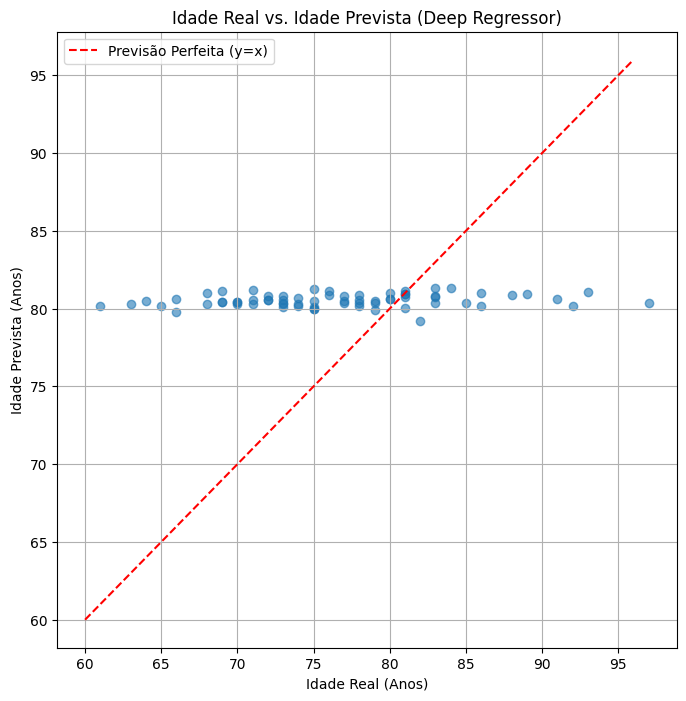

In [19]:
from sklearn.metrics import mean_absolute_error

# --- AVALIAÇÃO DO REGRESSOR (COM DESNORMALIZAÇÃO) ---

print("Avaliando Regressor de Idade no conjunto de teste...")

# 1. Avaliação do Keras (ainda na escala [0, 1])
results_reg_norm = reg_model.evaluate(test_ds_reg)
print("\nMétricas de Teste (na escala normalizada [0, 1]):")
print(f"Loss (MAE): {results_reg_norm[0]:.4f}")

# 2. Obter predições (escaladas em [0, 1])
y_pred_norm = reg_model.predict(test_ds_reg).flatten()

# 3. Obter idades reais (não-normalizadas)
# (Graças ao `is_training=False` no test_ds_reg, a ordem está correta)
y_true_real = test_paths_reg['age_original'].values

# 4. DESNORMALIZAR as predições
y_pred_real = (y_pred_norm * (age_max - age_min)) + age_min

# 5. Calcular MAE real (em anos)
mae_real = mean_absolute_error(y_true_real, y_pred_real)

print(f"\n===== RESULTADO FINAL =====")
print(f"O Erro Médio Absoluto (MAE) real é: {mae_real:.2f} anos.")

# 6. Plotar Gráfico de Dispersão (Idade Real vs. Idade Prevista)
plt.figure(figsize=(8, 8))
plt.scatter(y_true_real, y_pred_real, alpha=0.6)
plt.title('Idade Real vs. Idade Prevista (Deep Regressor)')
plt.xlabel('Idade Real (Anos)')
plt.ylabel('Idade Prevista (Anos)')

# Adiciona uma linha 'perfeita' (y=x) para referência
lims = [age_min, age_max] # Usar o min/max de treino para a linha
plt.plot(lims, lims, 'r--', label='Previsão Perfeita (y=x)')
plt.legend()
plt.grid(True)
plt.show()